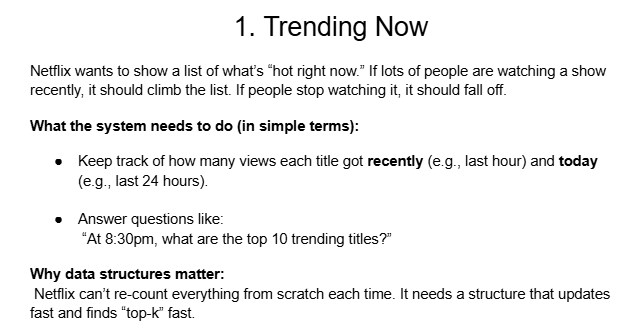

# **Setup functions**

In [44]:
from collections import deque
import heapq

hour_queue = deque()
day_queue = deque()
scores = {}
ops = {
    'queue_pushes': 0,
    'queue_pops': 0,
    'hashmap_lookups': 0,
    'hashmap_updates': 0,
    'heap_builds': 0,
    'heap_build_size': 0,
    'heap_extractions': 0
}

In [61]:
def expire(t):
    moved = 0
    expired = 0
    details = []
    while hour_queue and hour_queue[0][0] <= t - 60:
        ts, title = hour_queue.popleft()
        ops['queue_pops'] += 1
        ops['hashmap_lookups'] += 1
        ops['hashmap_updates'] += 2
        scores[title]['recent'] -= 1
        scores[title]['daily'] += 1
        day_queue.append((ts, title))
        ops['queue_pushes'] += 1
        moved += 1
        details.append(f"  -> ({ts},{title}) moved from hour to day")

    while day_queue and day_queue[0][0] <= t - 1440:
        ts, title = day_queue.popleft()
        ops['queue_pops'] += 1
        ops['hashmap_lookups'] += 1
        ops['hashmap_updates'] += 1
        scores[title]['daily'] -= 1
        if scores[title]['recent'] == 0 and scores[title]['daily'] == 0:
            del scores[title]
        expired += 1
        details.append(f"  -> ({ts},{title}) expired from day queue")

    return moved, expired, details

def view(t, title):
    moved, expired, details = expire(t)
    ops['hashmap_lookups'] += 1
    if title not in scores:
        scores[title] = {'recent': 0, 'daily': 0}
    ops['hashmap_updates'] += 1
    scores[title]['recent'] += 1
    hour_queue.append((t, title))
    ops['queue_pushes'] += 1
    print(f"[{title}] view added at t={t}, {moved} moved from hour to day, {expired} expired")
    for d in details:
        print(d)
    print()

def query(t, k):
    moved, expired, details = expire(t)
    print(f"[QRY] at t={t}, k={k}, {moved} moved from hour to day, {expired} expired")
    for d in details:
        print(d)
    print()
    print("Hash map:")
    for title, counts in scores.items():
        print(f"  {title}: {counts}")
    scored = []
    for title, counts in scores.items():
        s = 3 * counts['recent'] + 1 * counts['daily']
        scored.append((-s, title))
    heapq.heapify(scored)
    ops['heap_builds'] += 1
    ops['heap_build_size'] += len(scored)
    result = []
    for _ in range(min(k, len(scored))):
        neg_s, title = heapq.heappop(scored)
        result.append((title, -neg_s))
        ops['heap_extractions'] += 1
    print(f"Top {k}: {result}\n")

In [62]:
def get_trending(dataset):
    global hour_queue, day_queue, scores, ops
    hour_queue = deque()
    day_queue = deque()
    scores = {}
    ops = {
        'queue_pushes': 0,
        'queue_pops': 0,
        'hashmap_lookups': 0,
        'hashmap_updates': 0,
        'heap_builds': 0,
        'heap_build_size': 0,
        'heap_extractions': 0
    }
    for line in dataset.strip().split('\n'):
        parts = line.split(',')
        if parts[0] == 'VIEW':
            t, title = int(parts[1]), parts[2]
            view(t, title)
        elif parts[0] == 'QRY':
            t, k = int(parts[1]), int(parts[2])
            query(t, k)

    print("=== TOTAL OPERATION COUNTS ===")
    for op, count in ops.items():
        print(f"  {op}: {count}")

# **Scenarios**

# T1

In [63]:
t1 = '''VIEW,1,S1
VIEW,2,S2
VIEW,3,S1
VIEW,4,S3
VIEW,5,S2
VIEW,6,S1
VIEW,7,S4
VIEW,8,S2
VIEW,9,S3
VIEW,10,S2
VIEW,11,S5
VIEW,12,S1
VIEW,13,S3
VIEW,14,S2
VIEW,15,S6
QRY,15,3
VIEW,16,S2
VIEW,17,S2
VIEW,18,S3
QRY,18,3
VIEW,19,S1
VIEW,20,S1
QRY,20,5'''


In [64]:
get_trending(t1)

[S1] view added at t=1, 0 moved from hour to day, 0 expired

[S2] view added at t=2, 0 moved from hour to day, 0 expired

[S1] view added at t=3, 0 moved from hour to day, 0 expired

[S3] view added at t=4, 0 moved from hour to day, 0 expired

[S2] view added at t=5, 0 moved from hour to day, 0 expired

[S1] view added at t=6, 0 moved from hour to day, 0 expired

[S4] view added at t=7, 0 moved from hour to day, 0 expired

[S2] view added at t=8, 0 moved from hour to day, 0 expired

[S3] view added at t=9, 0 moved from hour to day, 0 expired

[S2] view added at t=10, 0 moved from hour to day, 0 expired

[S5] view added at t=11, 0 moved from hour to day, 0 expired

[S1] view added at t=12, 0 moved from hour to day, 0 expired

[S3] view added at t=13, 0 moved from hour to day, 0 expired

[S2] view added at t=14, 0 moved from hour to day, 0 expired

[S6] view added at t=15, 0 moved from hour to day, 0 expired

[QRY] at t=15, k=3, 0 moved from hour to day, 0 expired

Hash map:
  S1: {'rece

# T2

In [65]:
t2 = '''VIEW,5,L901
VIEW,6,L155
VIEW,7,L901
VIEW,8,L777
VIEW,9,L155
VIEW,10,L901
VIEW,11,L320
VIEW,12,L155
VIEW,13,L777
VIEW,14,L998
VIEW,15,L901
VIEW,16,L155
VIEW,17,L777
VIEW,18,L777
VIEW,19,L155
QRY,20,3
QRY,20,5'''

In [66]:
get_trending(t2)

[L901] view added at t=5, 0 moved from hour to day, 0 expired

[L155] view added at t=6, 0 moved from hour to day, 0 expired

[L901] view added at t=7, 0 moved from hour to day, 0 expired

[L777] view added at t=8, 0 moved from hour to day, 0 expired

[L155] view added at t=9, 0 moved from hour to day, 0 expired

[L901] view added at t=10, 0 moved from hour to day, 0 expired

[L320] view added at t=11, 0 moved from hour to day, 0 expired

[L155] view added at t=12, 0 moved from hour to day, 0 expired

[L777] view added at t=13, 0 moved from hour to day, 0 expired

[L998] view added at t=14, 0 moved from hour to day, 0 expired

[L901] view added at t=15, 0 moved from hour to day, 0 expired

[L155] view added at t=16, 0 moved from hour to day, 0 expired

[L777] view added at t=17, 0 moved from hour to day, 0 expired

[L777] view added at t=18, 0 moved from hour to day, 0 expired

[L155] view added at t=19, 0 moved from hour to day, 0 expired

[QRY] at t=20, k=3, 0 moved from hour to day,

# T3

In [67]:
t3 = '''VIEW,1,X
VIEW,2,X
VIEW,3,X
VIEW,4,X
VIEW,5,X
VIEW,6,A
VIEW,7,B
VIEW,8,C
VIEW,9,A
VIEW,10,B
VIEW,11,A
VIEW,12,C
QRY,12,3
VIEW,70,A
VIEW,71,A
VIEW,72,B
VIEW,73,B
VIEW,74,B
VIEW,75,C
QRY,75,3
QRY,76,3'''

In [68]:
get_trending(t3)

[X] view added at t=1, 0 moved from hour to day, 0 expired

[X] view added at t=2, 0 moved from hour to day, 0 expired

[X] view added at t=3, 0 moved from hour to day, 0 expired

[X] view added at t=4, 0 moved from hour to day, 0 expired

[X] view added at t=5, 0 moved from hour to day, 0 expired

[A] view added at t=6, 0 moved from hour to day, 0 expired

[B] view added at t=7, 0 moved from hour to day, 0 expired

[C] view added at t=8, 0 moved from hour to day, 0 expired

[A] view added at t=9, 0 moved from hour to day, 0 expired

[B] view added at t=10, 0 moved from hour to day, 0 expired

[A] view added at t=11, 0 moved from hour to day, 0 expired

[C] view added at t=12, 0 moved from hour to day, 0 expired

[QRY] at t=12, k=3, 0 moved from hour to day, 0 expired

Hash map:
  X: {'recent': 5, 'daily': 0}
  A: {'recent': 3, 'daily': 0}
  B: {'recent': 2, 'daily': 0}
  C: {'recent': 2, 'daily': 0}
Top 3: [('X', 15), ('A', 9), ('B', 6)]

[A] view added at t=70, 10 moved from hour to 